In [176]:
import jax
import jax.numpy as jnp
import jax.random as jr

import equinox as eqx

from klax import split_data
from klax.nn import MLP, Linear
from klax import fit

import optax

from jaxtyping import PRNGKeyArray, Array
from typing import Callable, Literal, Sequence

from scipy.io import loadmat

from matplotlib import pyplot as plt

jax.config.update("jax_enable_x64", True)

Ideas for tasks:
1. Train FNO normally
2. Superresolutoin
3. Cut training data in half (no longer priodic BC) -> Runges phenomenon, worse fit

In [3]:
def is_colab():
    """Determine if the code is running in Google Colab."""
    try:
        import google.colab

        return True
    except ImportError:
        return False


if is_colab():
    print("Running in Google Colab, trying to install LecturePhysicsAwareML...")
    !git clone --depth 1 https://github.com/Drenderer/LecturePhysicsAwareML.git

    # Get the data Mathworks (the creators of Matlab) host the original Li et al. dataset in the .mat format
    !wget https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat

    # Install the package
    %cd LecturePhysicsAwareML/dynamic_modeling
    %pip install -e .
    print(
        "\n************************************************************************************\nMake sure to restart the session after installation (Runtime > Restart Session).\n********************************************************************************"
    )
else:
    print(
        "Not running in Google Colab. \nPlease add the data and install the package manually if needed. The data can be downloaded here: https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat. \nIf you are using pip, run:\n>>> pip install -e .\nin the operator_learning directory."
    )


Not running in Google Colab. 
Please add the data and install the package manually if needed. The data can be downloaded here: https://ssd.mathworks.com/supportfiles/nnet/data/burgers1d/burgers_data_R10.mat. 
If you are using pip, run:
>>> pip install -e .
in the operator_learning directory.


In [177]:
# Load the data
if is_colab():
    data = loadmat(R"/content/burgers_data_r10.mat")
else:
    data = loadmat(R"../data/burgers_data_r10.mat")

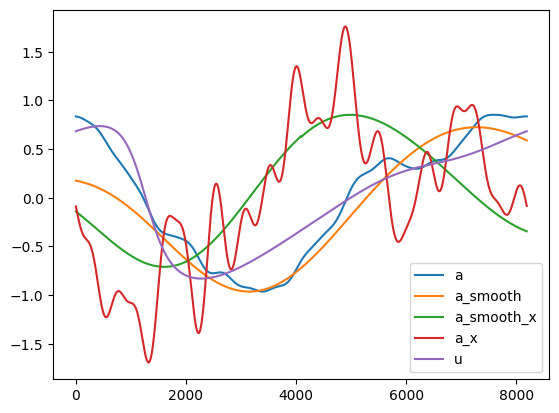

In [178]:
for key in data.keys():
    if not key.startswith("__"):
        plt.plot(data[key][0], label=key)
plt.legend()
plt.show()

In [179]:
u0, u1 = data["a"], data["u"]
x = jnp.linspace(0, 1, u0.shape[1])
print(u0.shape, u1.shape)

(2048, 8192) (2048, 8192)


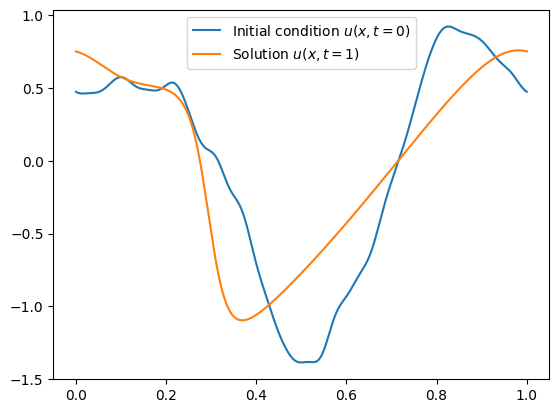

In [14]:
plt.plot(x, u0[1], label="Initial condition $u(x,t=0)$")
plt.plot(x, u1[1], label="Solution $u(x,t=1)$")
plt.legend()
plt.show()

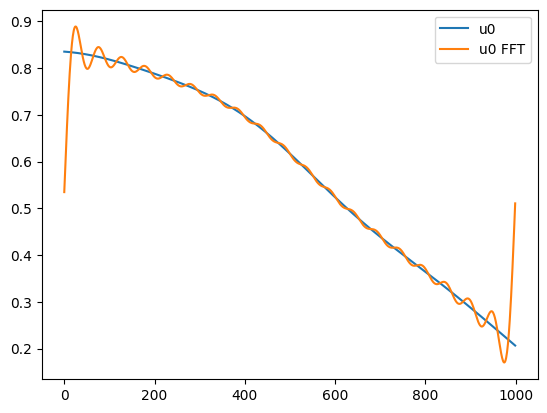

In [127]:
u = u0[0, :1000]
# u = jnp.pad(u, (u.size // 2, u.size // 2), mode="symmetric")
u_fft = jnp.fft.rfft(u)
u_ = jnp.fft.irfft(u_fft[:20], n=u.shape[-1])

plt.plot(u.real, label="u0")
plt.plot(u_.real, label="u0 FFT")
plt.legend()
plt.show()

In [79]:
class LiftingLayer1D(eqx.Module):
    mlp: MLP

    def __init__(
        self,
        in_channels: int | Literal["scalar"],
        out_channels: int | Literal["scalar"],
        width_sizes: Sequence[int] = [16, 16],
        activation: Callable[[Array], Array] = jax.nn.softplus,
        *,
        key: PRNGKeyArray,
    ):
        self.mlp = MLP(
            in_size=in_channels,
            out_size=out_channels,
            width_sizes=width_sizes,
            activation=activation,
            key=key,
        )

    def __call__(self, x: Array):
        return jax.vmap(self.mlp)(x)


class SpectralConvolution1D(eqx.Module):
    weight_real: Array
    weight_imag: Array
    num_modes: int  #: Number of nodes to retain

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        num_modes: int,
        *,
        key: PRNGKeyArray,
    ):
        weight_shape = (num_modes, in_channels, out_channels)
        
        scale = 1 / (in_channels * out_channels)
        weight_real_key, weight_imag_key = jr.split(key)

        self.weight_real = jr.uniform(
            weight_real_key, weight_shape, minval=-scale, maxval=scale
        )
        self.weight_imag = jr.uniform(
            weight_imag_key, weight_shape, minval=-scale, maxval=scale
        )

        self.num_modes = num_modes

    def __call__(self, x: Array):
        """_summary_

        Args:
            x: shape=(n, in_channels)
        """

        num_space, in_channels = x.shape

        if num_space // 2 + 1 < self.num_modes:
            raise ValueError(f"The data discretization is to coarse for the given number of modes. (Modes: {self.num_modes}, data points: {num_space})")

        # Apply real valued fft. x_ft.shape = (num_space // 2 + 1)
        x_ft = jnp.fft.rfft(x, axis=0)
        # Truncate to num_modes
        x_ft = x_ft[: self.num_modes, :]
        # Multiply by complex weights
        weight = self.weight_real + 1j * self.weight_imag
        out_ft = jnp.einsum("xc,xio->xo", x_ft, weight)
        # Inverse FFT
        out_ift = jnp.fft.irfft(out_ft, n=num_space, axis=0)

        return out_ift


class FNOLayer(eqx.Module):
    spectral_conv: SpectralConvolution1D
    linear: Linear  #: Linear part of the FNO layer
    activation: Callable

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        num_modes: int,
        activation: Callable = jax.nn.softplus,
        *,
        key: PRNGKeyArray,
    ):
        spectral_key, linear_key = jr.split(key)
        self.spectral_conv = SpectralConvolution1D(
            in_channels, out_channels, num_modes, key=spectral_key
        )
        self.linear = Linear(
            in_channels,
            out_channels,
            weight_init=jax.nn.initializers.variance_scaling(
                0.1, "fan_avg", "truncated_normal"
            ),
            key=linear_key,
        )
        self.activation = activation

    def __call__(self, x: Array):

        return self.activation(
            self.spectral_conv(x) #+ jax.vmap(self.linear)(x)
        )


class FNO(eqx.Module):
    lifting: MLP
    projection: MLP
    layers: list[FNOLayer]

    def __init__(
        self,
        in_channels: int | Literal["scalar"],
        out_channels: int | Literal["scalar"],
        num_modes: int,
        hidden_channels: int,
        depth: int = 3,
        *,
        key: PRNGKeyArray,
    ):
        p_key, q_key, l_key = jr.split(key, 3)
        self.lifting = MLP(
            in_size=in_channels,
            out_size=hidden_channels,
            width_sizes=[16, 16],
            activation=jax.nn.softplus,
            key=p_key,
        )
        self.projection = MLP(
            in_size=hidden_channels,
            out_size=out_channels,
            width_sizes=[16, 16],
            activation=jax.nn.softplus,
            key=q_key,
        )
        self.layers = [
            FNOLayer(hidden_channels, hidden_channels, num_modes, key=k)
            for k in jr.split(l_key, depth)
        ]

    def __call__(self, x):
        # Pointwise application of the lifting function
        x = jax.vmap(self.lifting)(x)
        # Iterate over FNO layers
        for layer in self.layers:
            x = layer(x)
        # Pointwise application of the projection function
        return jax.vmap(self.projection)(x)

In data shape = (2048, 8192, 2) (batch, space, channel)


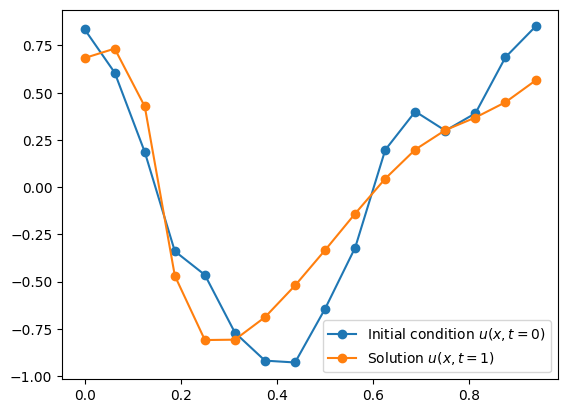

In [86]:
# Generate coarse grained and fine grained datasets

batched_x = jnp.repeat(x[None, :], u0.shape[0], axis=0)
in_data = jnp.stack([u0, batched_x], axis=-1)

print("In data shape =", in_data.shape, "(batch, space, channel)")

dataset_fine = (u0, u1)
se = 2**9  # Sample every se-th datapoint for the coarse grain data
dataset_coarse = (u0[:, ::se], u1[:, ::se])
x_coarse = x[::se]

plt.plot(
    x_coarse, dataset_coarse[0][0, :], marker="o", label="Initial condition $u(x,t=0)$"
)
plt.plot(x_coarse, dataset_coarse[1][0], marker="o", label="Solution $u(x,t=1)$")
plt.legend()
plt.show()

In [87]:
key = jr.key(1)
key_split, model_key, training_key = jr.split(key, 3)

train_data_coarse, test_data_coarse = split_data(
    dataset_coarse, (0.9, 0.1), batch_axis=0, key=key_split
)
train_data_fine, test_data_fine = split_data(
    dataset_fine, (0.9, 0.1), batch_axis=0, key=key_split
)

Step: 0, Loss: 2.419e-01, Validation loss: 2.439e-01
Step: 100, Loss: 3.733e-02, Validation loss: 3.826e-02
Step: 200, Loss: 2.065e-02, Validation loss: 2.084e-02
Step: 300, Loss: 1.283e-02, Validation loss: 1.236e-02
Step: 400, Loss: 9.104e-03, Validation loss: 8.825e-03
Step: 500, Loss: 6.575e-03, Validation loss: 6.410e-03
Step: 600, Loss: 5.346e-03, Validation loss: 5.335e-03
Step: 700, Loss: 4.606e-03, Validation loss: 4.688e-03
Step: 800, Loss: 3.899e-03, Validation loss: 3.989e-03
Step: 900, Loss: 3.390e-03, Validation loss: 3.535e-03
Step: 1000, Loss: 2.922e-03, Validation loss: 3.031e-03
Step: 1100, Loss: 2.479e-03, Validation loss: 2.575e-03
Step: 1200, Loss: 2.136e-03, Validation loss: 2.243e-03
Step: 1300, Loss: 1.848e-03, Validation loss: 1.969e-03
Step: 1400, Loss: 1.629e-03, Validation loss: 1.732e-03
Step: 1500, Loss: 1.474e-03, Validation loss: 1.576e-03
Step: 1600, Loss: 1.326e-03, Validation loss: 1.415e-03
Step: 1700, Loss: 1.214e-03, Validation loss: 1.293e-03
Step

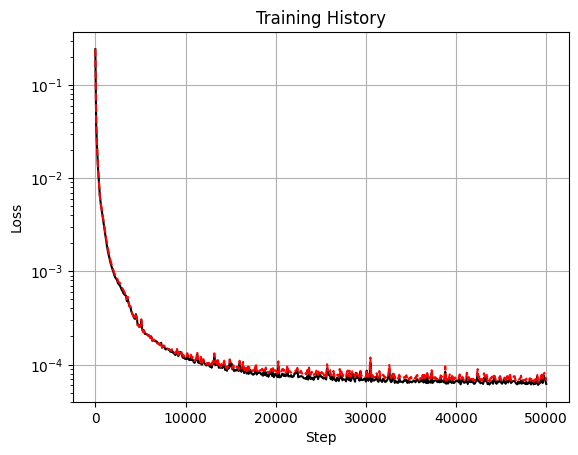

In [ ]:
fno = FNO("scalar", "scalar", num_modes=9, hidden_channels=10, depth=2, key=model_key)

fno, history = fit(
    fno,
    train_data_coarse,
    batch_size=64,
    validation_data=test_data_coarse,
    steps=50_000,
    optimizer=optax.adam(1e-4),
    key=training_key,
)

history.plot()  # type: ignore

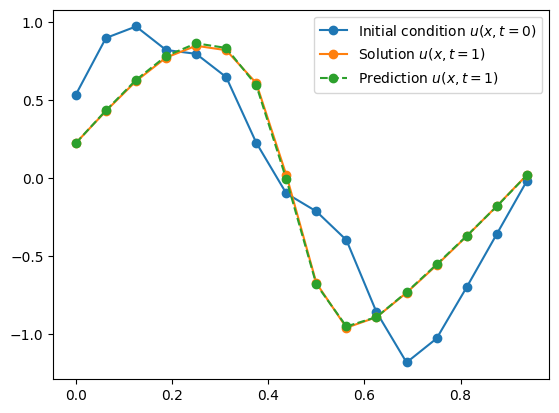

In [129]:
## Evaluation
u0_test, u1_test = test_data_coarse

u1_test_pred = jax.vmap(fno)(u0_test)

n = 1

plt.plot(x_coarse, u0_test[n, :],   marker="o", label="Initial condition $u(x,t=0)$")
plt.plot(x_coarse, u1_test[n],      marker="o", label="Solution $u(x,t=1)$")
plt.plot(x_coarse, u1_test_pred[n], marker="o", ls="--", label="Prediction $u(x,t=1)$")
plt.legend()
plt.show()


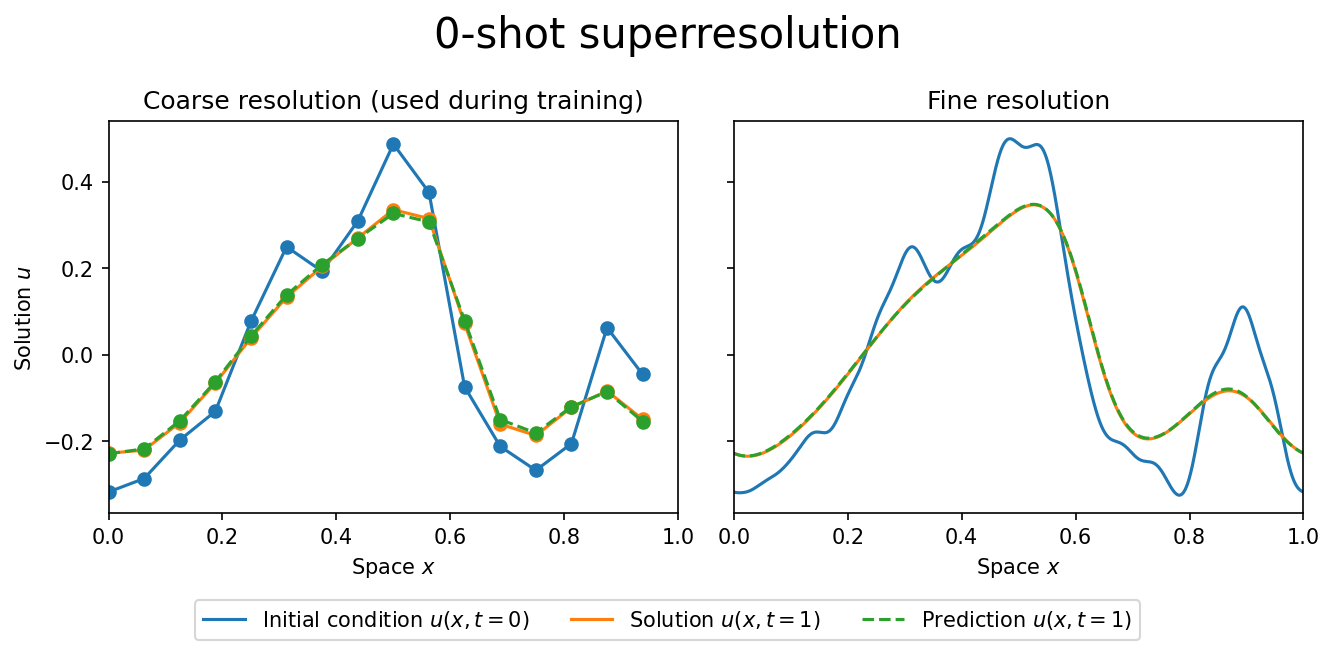

In [128]:
## Try 0-shot superresolution
n = 2   # Index of the test case in the test dataset

u0_test_coarse, u1_test_coarse = test_data_coarse
u0_test_fine, u1_test_fine = test_data_fine

u1_test_coarse_pred = fno(u0_test_coarse[n])
u1_test_fine_pred = fno(u0_test_fine[n])

fig, axes = plt.subplots(1, 2, figsize=(9,4), dpi=150, sharey=True)

axes[0].plot(x_coarse, u0_test_coarse[n],   marker="o", label="Initial condition $u(x,t=0)$")
axes[0].plot(x_coarse, u1_test_coarse[n],   marker="o", label="Solution $u(x,t=1)$")
axes[0].plot(x_coarse, u1_test_coarse_pred, marker="o", ls="--", label="Prediction $u(x,t=1)$")
axes[0].set(
    xlabel = "Space $x$",
    xlim = [0, 1],
    ylabel = "Solution $u$",
    title  = "Coarse resolution (used during training)",
)

axes[1].plot(x, u0_test_fine[n], label="Initial condition $u(x,t=0)$")
axes[1].plot(x, u1_test_fine[n], label="Solution $u(x,t=1)$")
axes[1].plot(x, u1_test_fine_pred, ls="--", label="Prediction $u(x,t=1)$")
axes[1].set(
    xlabel = "Space $x$",
    xlim = [0, 1],
    title  = "Fine resolution",
)
# Combine handles and labels from both axes
handles, labels = axes[1].get_legend_handles_labels()

# Place the legend below both plots, centered, in one line
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=len(labels), frameon=True)
fig.suptitle("0-shot superresolution", fontsize=20)
plt.tight_layout()
plt.show()

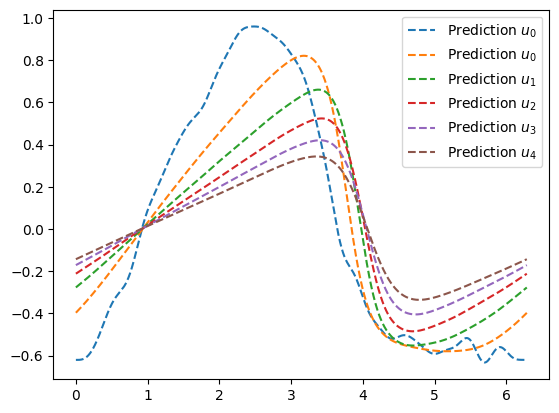

In [199]:
## Trying out autoregressive unrolling
u0_test_fine, u1_test_fine = test_data_fine

pred = u0_test_fine[0]
plt.plot(x, pred, ls="--", label="Prediction $u_0$")
for i in range(5):
    pred = fno(pred)
    plt.plot(x, pred, ls="--", label=f"Prediction $u_{i}$")

plt.legend()
plt.show()